In [70]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import polars as pl
from datetime import datetime

In [ ]:
# Load data
col = 'solar_radiation'
to_forecast = (
    pl
    .read_csv("weatherstats_toronto_daily.csv", schema_overrides = {"cooldegdays": pl.Float64})
    .select(["date", "max_temperature", "min_temperature"])
    )

# Transform it for plotting
to_forecast = (
    to_forecast
    .with_columns(
        pl.col("date").str.strptime(pl.Date, "%Y-%m-%d").alias("date_parsed")
    )
    .with_columns([
        pl.col("date_parsed").dt.year().alias("year"),
        pl.col("date_parsed").dt.month().alias("month")
    ])
    .filter(pl.col("year") > 1979, pl.col("year") < 2025)
    .group_by(["year", "month"])
    .agg([
        pl.col("max_temperature").mean().alias("mean_max_temperature"),
        pl.col("min_temperature").mean().alias("mean_min_temperature")
    ])
    .sort(["year", "month"], descending=False)
    .with_columns(
        pl.int_range(0, pl.count()).reverse().alias("position")
    )
    .drop_nulls()
)

/tmp/ipykernel_18881/911263507.py:28: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.int_range(0, pl.count()).reverse().alias("position")


/tmp/ipykernel_18881/2503645397.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_max = cm.get_cmap("Reds")
/tmp/ipykernel_18881/2503645397.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_min = cm.get_cmap("Blues")


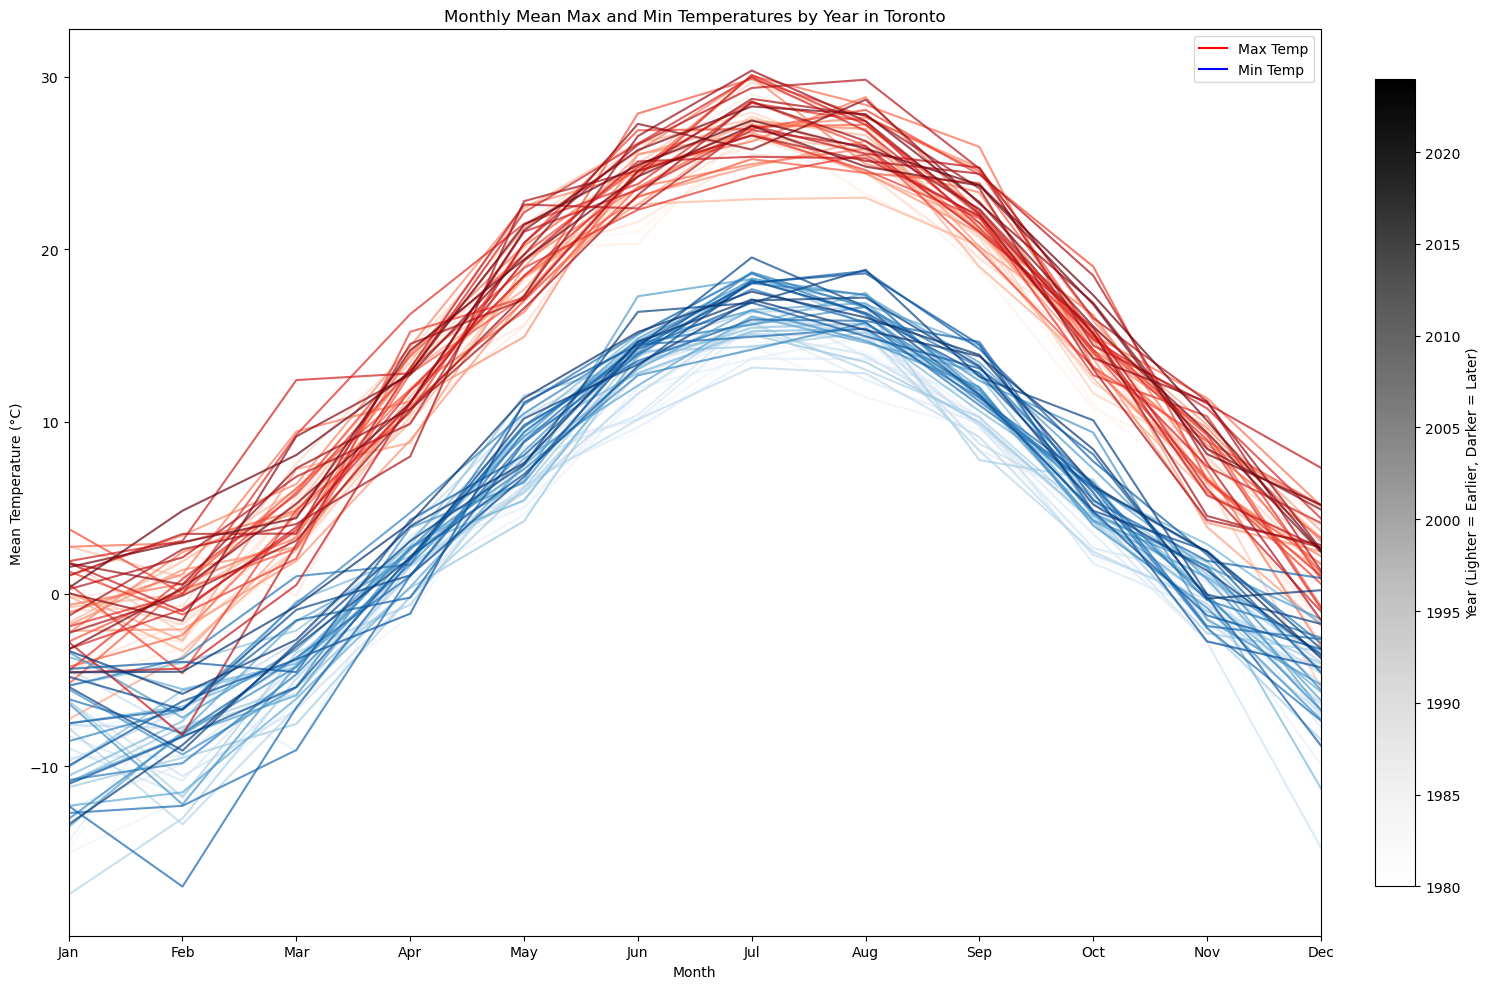

In [82]:
fig, ax = plt.subplots(figsize=(15, 10))

# Define colormap
cmap_gray = plt.get_cmap("Greys")
cmap_max = cm.get_cmap("Reds")
cmap_min = cm.get_cmap("Blues")

# Normalize the colormap based on the years
norm = plt.Normalize(vmin=min(to_forecast["year"]), vmax=max(to_forecast["year"]))

# Loop through each year and plot
for year in to_forecast["year"].unique():
    year_data = to_forecast.filter(pl.col("year") == year).sort("month")
    
    max_color = cmap_max(norm(year))
    min_color = cmap_min(norm(year))

    ax.plot(year_data["month"], year_data["mean_max_temperature"], color=max_color, alpha=0.7)
    ax.plot(year_data["month"], year_data["mean_min_temperature"], color=min_color, alpha=0.7)

# labels and title
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", 
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlabel("Month")
ax.set_ylabel("Mean Temperature (°C)")
ax.set_title("Monthly Mean Max and Min Temperatures by Year in Toronto")

# red/blue legend
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0], [0], color="red", label="Max Temp"),
    Line2D([0], [0], color="blue", label="Min Temp")
]
ax.legend(handles=legend_lines, loc="upper right")

# colourbar defining early and late years
sm = plt.cm.ScalarMappable(cmap=cmap_gray, norm=norm)
sm.set_array([])  # Required for colorbar to show
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.03, pad=0.04)
cbar.set_label("Year (Lighter = Earlier, Darker = Later)")

# set limit so lines touch edges of plot
ax.set_xlim(1, 12)

plt.tight_layout()
plt.savefig("/mnt/c/Users/peree/OneDrive/Documents/UofT-DSI/visualization/02_activities/assignments/min_max_averages.png", dpi=500)
plt.show()